# PROJECT

## Loading and Cleaning Data

The data I have chosen is from KaggleHub. The dataset describes the real-time lightning strikes during a period of a week in December 2025(17-23 of December 2025). With the help of this data I am trying to make a model that predicts the lightning strike areas and try to find hot-spots with K-clustering. The libraries necessary for this is shown below.

This notebook consists of data cleaning, visual analysis, analysis using supervised and unsupervised data, loading additional data from OpenMeteo API, exporting of results and analysis of results. 

The data is automatically imported from kagglehub and OpenMeteo and is cleaned and handled in this notebook. To use this notebook dowload and import the libraries below and the restart kernel and run it from top to bottom. 

In [4]:
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import requests
from IPython.display import Image


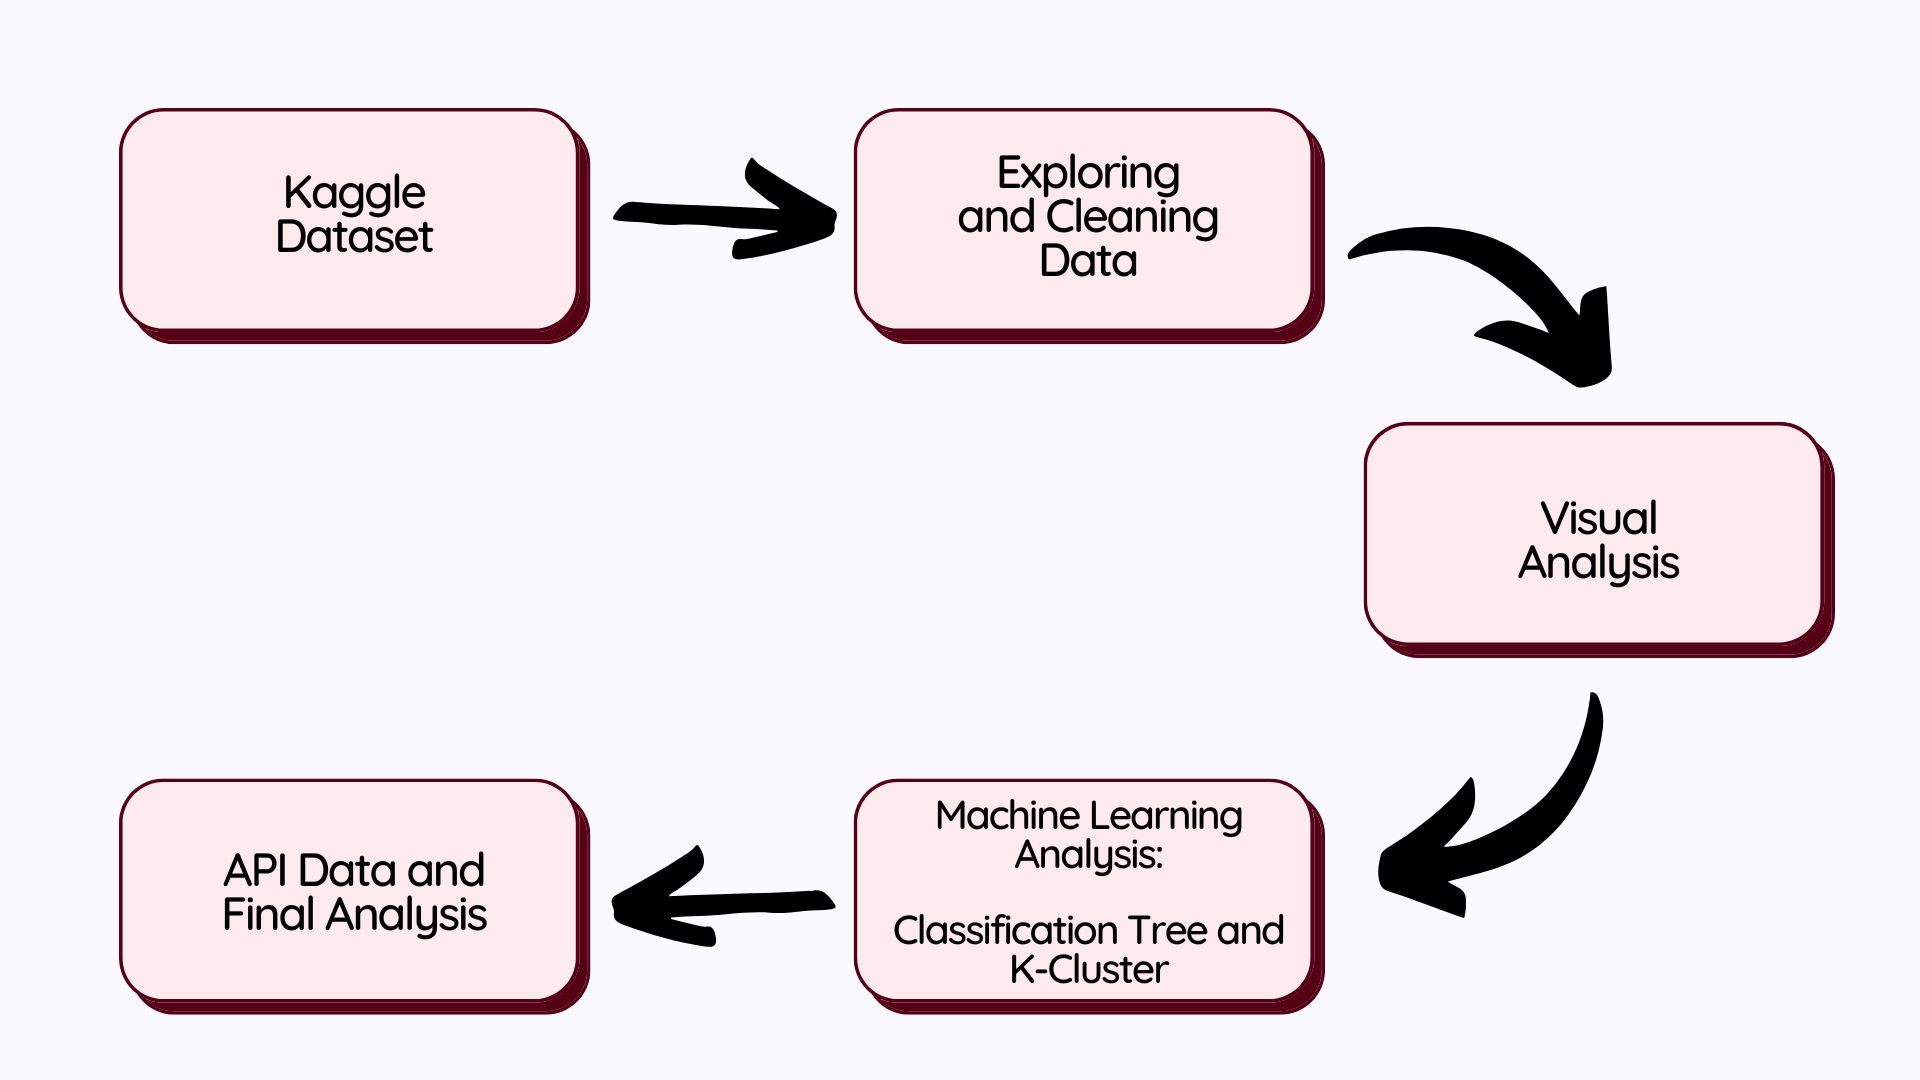

In [5]:
Image("chart.png")


The data has 7 variables. 

These variables are: 


time: which describes the exakt moment of lightning strike, in the unit Unix  timestamp


lat: latitude


lon: longitude 


region: geographic region identifier (1-14)


mds: minimum detectable signal (measurement for signal strength)


mcg: maximum circular gap (how close the signal-receiving stations are from  the strike) (the information from this one was not on kaggle but I found it here https://www.mdpi.com/2073-4433/14/10/1507)


status: there is no clear description of thi Claudene (when I gave AI the site from where the owner of the data got the information from, AI suggested that it might be how many lighting dectector stations that registered the lightning strike)

The two last variables that were not described in Kaggle. It seems that the data set was changed but the descriptions were not updated. I have tried my best to look up what these variables. The creator of the data provided the site from where they have found the information, so with the help of that site and AI this are the descriptions that I have found but especially the status variable, the description is merely a guess.

I will also add a 8th variable called time_date that shows the "normal" time to make the data more interpretable, since the time is given in Unix timestamp in the data. 

In [9]:

# Download latest version
path = kagglehub.dataset_download("vivektiwari020801/real-time-lightning-strikes")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\sandr\.cache\kagglehub\datasets\vivektiwari020801\real-time-lightning-strikes\versions\640


In [10]:
print(os.listdir(path))
lightningdata = pd.read_csv(os.path.join(path, "lightning.csv"))
lightningdata.head()

['lightning.csv']


,time,lat,lon,region,mds,mcg,status
0,1765963807212409088,28.194713,-96.328267,1,7609,200,22
1,1765963809812001280,27.517726,-95.683990,1,8074,238,17
2,1765963814515200000,27.276969,-97.171758,1,10556,212,20
3,1765963814718639360,26.555502,-97.758053,1,9205,218,19
4,1765963814768915200,26.572890,-97.731561,1,6208,215,17


To begin with I will look over the data and see if there are problems in the data that need handling. 

In [12]:
lightningdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742543 entries, 0 to 742542
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   time    742543 non-null  int64  
 1   lat     742543 non-null  float64
 2   lon     742543 non-null  float64
 3   region  742543 non-null  int64  
 4   mds     742543 non-null  int64  
 5   mcg     742543 non-null  int64  
 6   status  742543 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 39.7 MB


In [13]:
lightningdata.isna().sum()

time      0
lat       0
lon       0
region    0
mds       0
mcg       0
status    0
dtype: int64

When looking at the output from info() and the is.na() code it seems that this data has no missing values at all. This does makes sense since this data contains information of where a lightning has struck and this means that all information in all variables should be recorded. The lightning cannot really strike with only latittude etc.

In [15]:
#creating another column since the time is in Unix timestamps 
lightningdata["time_date"] = pd.to_datetime(lightningdata["time"], unit="ns")

print("Summary Statistics")
lightningdata.describe().round(2)

Summary Statistics


,time,lat,lon,region,mds,mcg,status,time_date
count,7.425430e+05,742543.00,742543.00,742543.00,742543.00,742543.00,742543.00,742543
mean,1.766247e+18,19.10,-35.82,5.98,8875.19,224.25,48.59,2025-12-20 16:09:45.419842816
min,1.765961e+18,-46.69,-179.40,1.00,382.00,41.00,9.00,2025-12-17 08:45:05.413384704
25%,1.766140e+18,18.59,-94.97,2.00,6355.00,203.00,21.00,2025-12-19 10:23:50.105729024
50%,1.766209e+18,22.60,-78.79,4.00,8727.00,235.00,28.00,2025-12-20 05:37:13.409732864
75%,1.766389e+18,31.86,10.76,12.00,11448.00,251.00,48.00,2025-12-22 07:44:20.433736960
max,1.766529e+18,71.49,179.93,14.00,14999.00,270.00,565.00,2025-12-23 22:33:54.758820864
std,1.508314e+14,19.98,86.79,4.53,3214.08,36.46,60.88,NaN


In the summary stats it can be seen even more clearly that when the lightning strikes all these variables take on a value. In the summary statistics it can be seen that no variable has a minimum value of zero, meaning that none of these variables are always taking on a value. The latitude and the longitude are obviously exceptions to this. Latitude can take values between -90 and +90, and longitude can take values between -180 and +180. As can be seen from the maximum and minimum values in the summary statistics the lat and lon are staying within this range, indicating that these values seem to be reasonable. It would obviously be a clear sign of problems if the lat and lon were not staying in the range they are supposed to be in. 

In the print of the summary statistcs the new column for date and time can be seen. I opted for creating another column to increase inpretability, the Unix makes sense to measure lightning strikes since they happen very suddenly and quickly it requires a small unit of time measure. However, it is difficult to interpret the time period for this dataset if one is not familiar with Unix. 

In [18]:
print("Correlation Analysis")
print(lightningdata.corr())

Correlation Analysis
               time       lat       lon    region       mds       mcg  \
time       1.000000 -0.050480  0.143750 -0.069208  0.007231  0.032290   
lat       -0.050480  1.000000 -0.631791  0.342480 -0.136957  0.096154   
lon        0.143750 -0.631791  1.000000 -0.301716  0.151281 -0.224797   
region    -0.069208  0.342480 -0.301716  1.000000 -0.103128  0.030329   
mds        0.007231 -0.136957  0.151281 -0.103128  1.000000 -0.218375   
mcg        0.032290  0.096154 -0.224797  0.030329 -0.218375  1.000000   
status     0.186090  0.321247  0.071175  0.139903 -0.085166 -0.077857   
time_date  1.000000 -0.050480  0.143750 -0.069208  0.007231  0.032290   

             status  time_date  
time       0.186090   1.000000  
lat        0.321247  -0.050480  
lon        0.071175   0.143750  
region     0.139903  -0.069208  
mds       -0.085166   0.007231  
mcg       -0.077857   0.032290  
status     1.000000   0.186090  
time_date  0.186090   1.000000  


## Visual Analysis

Map showing the lightning strikes by region, because the regions are not defined in the data


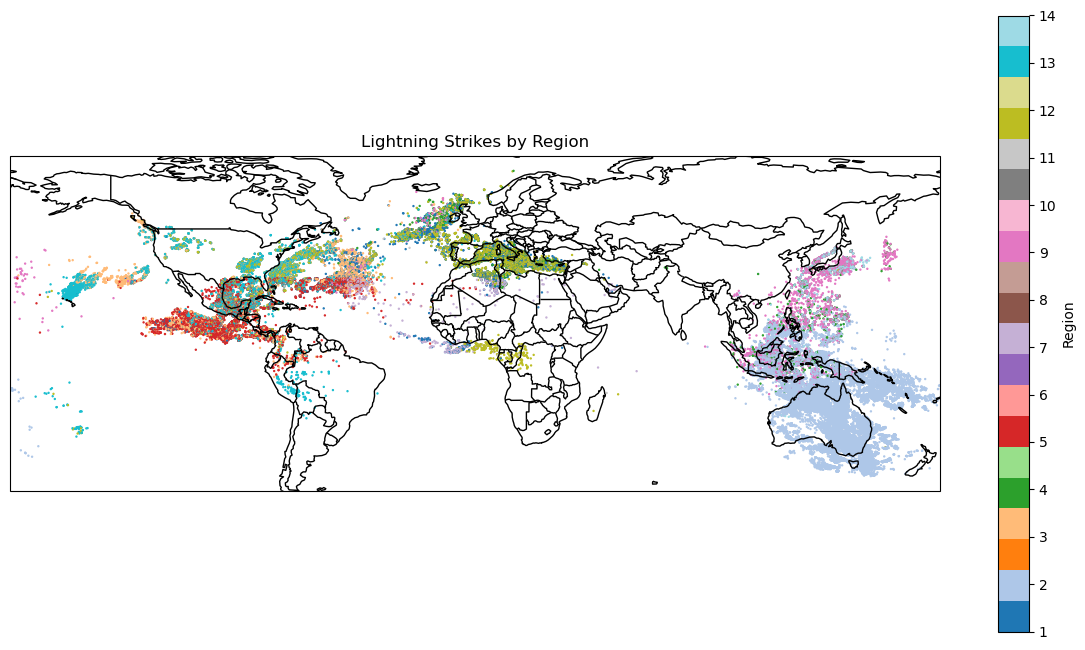

In [20]:

print("Map showing the lightning strikes by region, because the regions are not defined in the data")

fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

scatter = ax.scatter(lightningdata["lon"], lightningdata["lat"],
                     c=lightningdata["region"], cmap="tab20", s=0.5, transform=ccrs.PlateCarree(),
                    vmin=1, vmax=14)
cbar = fig.colorbar(scatter, ax = ax, label='Region')
cbar.set_ticks(range(1, 15))  # tick for every region 1-14
cbar.set_ticklabels(range(1, 15))
plt.title("Lightning Strikes by Region")
plt.show()

What can be seen here in the map is that some regions overlap a lot with each other. This might make predicting more difficult for the model since differnt regions observations are so close to each other the information that the models will have to predict on is very similar. For the time of the year the data seems kind of logical, there being very few lightning strikes in the north and there being  a lot of lightning strikes in Australia and Oceania, where there at this time would be summer and very warm. In other words good climate for lightning strikes. 

In [22]:
#find the regiion centers
region_centers = lightningdata.groupby("region")[["lat", "lon"]].mean()
display(region_centers)

,lat,lon
region,,
1,32.827914,-30.010150
2,-23.208500,140.506908
3,24.774240,-87.783718
4,35.190684,29.928230
5,20.549690,-92.316856
7,24.800631,-20.736951
9,27.126123,101.912993
11,35.143638,-14.854811
12,33.572598,-22.456453


These region centers will be used later on with my API data.

## Splitting Data for Statistical Analysis

In [25]:
y = lightningdata["region"]
X = lightningdata[["lat", "lon", "mds", "mcg"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
display(y)
display(X)

0          1
1          1
2          1
3          1
4          1
          ..
742538    12
742539    12
742540    12
742541    12
742542    12
Name: region, Length: 742543, dtype: int64

,lat,lon,mds,mcg
0,28.194713,-96.328267,7609,200
1,27.517726,-95.683990,8074,238
2,27.276969,-97.171758,10556,212
3,26.555502,-97.758053,9205,218
4,26.572890,-97.731561,6208,215
...,...,...,...,...
742538,39.265116,15.864834,9620,178
742539,39.268549,15.868015,3919,255
742540,39.272720,15.878483,5699,251
742541,39.432147,15.828402,5272,211


## Statistical Analysis

### Classification Tree 

I am starting with doing a classification tree. With this model I am going to try to predict the region that the lightning has struck in depending on lat, lon and mds. I am excluding the time variables, status and mcg from this model. The time variables will not add anything to the predictions in this model and considering I am not entirely sure about what the status variable describes it might just cause difficulty in predicting for the model. Because of the size of my dataset, over 700 000 observations, I have chosen to use a normal classification tree and not a method like RandomForest. This is because it with a data set of this size it would RandomForest requires a lot of computational power and a data set of this size is probably okay on its own without the RandomForest.

In [29]:
#choosing the model
sl_model = DecisionTreeClassifier(random_state = 42) #random_state makes the results recreateable otherwise the random values would change with every rerun 
sl_model.fit(X_train, y_train) #training the model

DecisionTreeClassifier(random_state=42)

In [30]:
#creating predictions for evaluating the model
predictions = sl_model.predict(X_test)

In [31]:
#evaluating the model 
print("Confusion Matrix")
print(confusion_matrix (y_test, predictions))

print("Classification Report")
print(classification_report(y_test, predictions))

Confusion Matrix
[[ 8669     0  1653  1126  1250   107    78  1272  8298  1264     0]
 [    0 32260     0   268     0     0   319     0     1     0   208]
 [ 1798     0 18182    69  8679    52    69   127  1326 18741     0]
 [ 1101   278    87  2378    36    17   378   237  1100    29   148]
 [ 1370     0  9560    34 22260    87    21    92   869  7430     0]
 [  144     0    70    14    63   235     0     4    24     0     0]
 [   75   460    55   371    12     1  1056     5    37    33   238]
 [ 1161     0   124   184    77     1     6   232  1346   129     0]
 [ 8400     0  1172   951   776    18    31  1450  6747  1235     0]
 [ 1286     0 18311    31  6793     0    18   155  1261 13895     0]
 [    0   237     0   163     0     0   255     0     0     0    93]]
Classification Report
              precision    recall  f1-score   support

           1       0.36      0.37      0.36     23717
           2       0.97      0.98      0.97     33056
           3       0.37      0.37     

The classification model has an accuracy of 0.48. Considering that there if you were splitting by chance into 14 groups that would indicate an accuarcy level of around 9% then 48% is not that bad. There is also not observations in all 14 regions during this weeks time of data, which makes sense since the data does not span over a long time, the model does however not predict into the empy regions. The regions with observations are listed in the K-clustering part. There are also probably a lot of other factors than the ones given in the dataset that would be needed to acutally forecast lightning strike regions with high precision. 

It can also be seen that for region number 2 the model is performing very well with an f1 score of 0.97. The model performs the worst with group 11, where the f1 score is 0.07. Region 2 is a larger region and region 11 is smaller regions. Classification models tend to have a harder time learning from small groups so this seems logical. 

### K-clustering

I have decided to use k-clustering to look at hotspot regions for lightning strikes. I have used k-clustering because my data set is so large that hierarchical clustering would be very computationally demanding. I will choose the same amount of clusters as regions. However there are not observations in all 14 regions, only 11, which can be seen below. So I will choose to have 11 clusters. 

In [35]:
lightningdata["region"].unique()

array([ 1,  2,  3,  4,  5,  9, 13, 14, 11, 12,  7], dtype=int64)

In [36]:

#scaling the observations for the K-clustering

scaler_standard = StandardScaler()
X_scaled = scaler_standard.fit_transform(lightningdata[["lat", "lon"]])

kmeans = KMeans(n_clusters = 11, random_state = 42)
lightningdata["cluster"] = kmeans.fit_predict(X_scaled)

In [37]:
print(lightningdata["cluster"].value_counts().sort_index())
print(lightningdata["region"].value_counts().sort_index())

cluster
0     121799
1      37743
2     114623
3      34045
4      10659
5      24216
6     147107
7      40009
8       9490
9     161201
10     41651
Name: count, dtype: int64
region
1      79030
2     110223
3     163055
4      19205
5     139897
7       1843
9       7657
11     10820
12     69021
13    139412
14      2380
Name: count, dtype: int64


What can be seen here is that the 11 clusters do not match the 11 regions with observations that already existed in the data. The k-clusters are basing the clustering on latitude and longitude of lightning strikes and have through this found different clusters. Both the clusters and the region groups are uneven which indicates that some regions have more ligthning strike activity than others. It seems as the klusters have evened out the groups a bit more than in the original regions. When looking it the regions and clusters there exists more regions with just a few observations than really small clusters. 

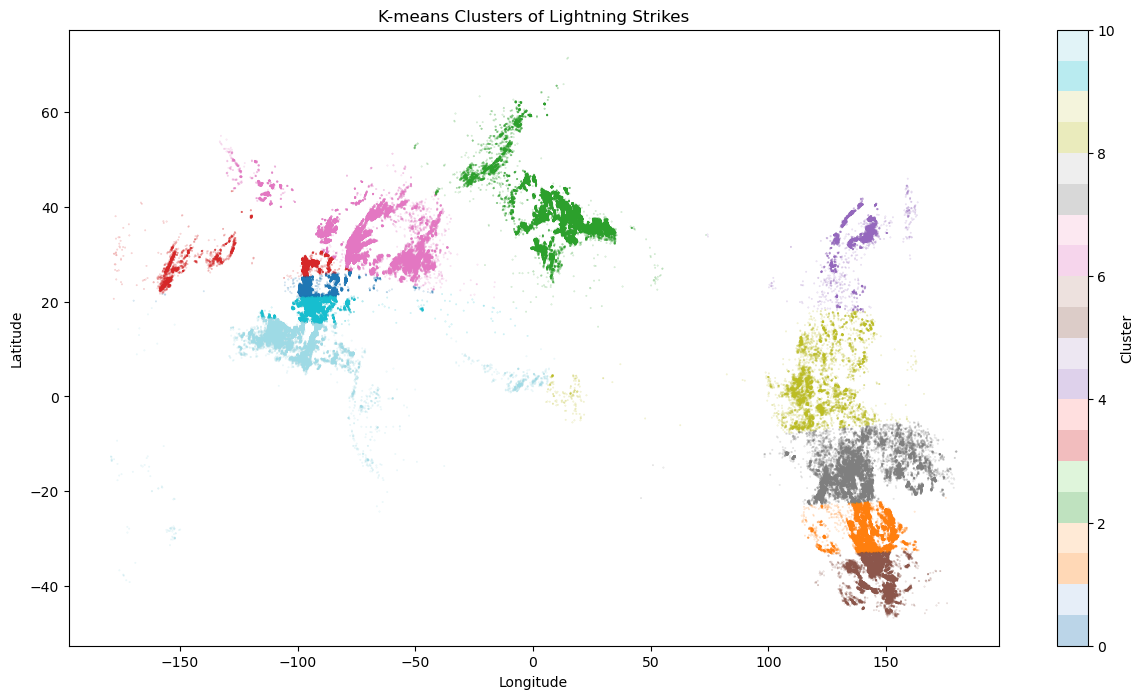

In [39]:
plt.figure(figsize=(15, 8))
plt.scatter(lightningdata["lon"], lightningdata["lat"], 
            c=lightningdata["cluster"], cmap="tab20", s=0.1, alpha=0.3)
plt.colorbar(label="Cluster")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-means Clusters of Lightning Strikes")
plt.show()

Here above is the K-clusters mapped out on a graph. When comparing to the map with the regions it can be seen that the regions are sorted much nicer with the k-clusters and regions are no longer overlapping with each other. Region 2 with a lot of observations have also been split into several clusters, whereas the small overlapping groups have been joined into larger clusters.

### API Data - Open-Meteo

In [42]:


def get_weather(lat, lon, region):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {"latitude": lat, 
              "longitude": lon, 
              "start_date": "2025-12-17", 
              "end_date": "2025-12-23", 
              "daily": "temperature_2m_max,precipitation_sum,windspeed_10m_max"
             } 
    response = requests.get(url, params = params)
    data = response.json()
    df = pd.DataFrame(data["daily"])
    df["region"] = region
    return df

all_regions = lightningdata["region"].unique()
weather_dfs = []

for region in all_regions:
    lat = region_centers.loc[region, "lat"]
    lon = region_centers.loc[region, "lon"]
    weather_df = get_weather(lat, lon, region)
    weather_dfs.append(weather_df)
    print(f"Fetched weather for region {region}")

weather_data = pd.concat(weather_dfs)

weather_data = weather_data.sort_values(["region", "time"]).reset_index(drop=True)
pd.set_option("display.max_rows", None)
display(weather_data)


Fetched weather for region 1
Fetched weather for region 2
Fetched weather for region 3
Fetched weather for region 4
Fetched weather for region 5
Fetched weather for region 9
Fetched weather for region 13
Fetched weather for region 14
Fetched weather for region 11
Fetched weather for region 12
Fetched weather for region 7


,time,temperature_2m_max,precipitation_sum,windspeed_10m_max,region
0,2025-12-17,21.1,0.0,28.6,1
1,2025-12-18,21.1,5.6,33.1,1
2,2025-12-19,19.2,0.0,28.0,1
3,2025-12-20,19.6,0.2,33.2,1
4,2025-12-21,18.6,0.0,28.1,1
5,2025-12-22,19.0,0.0,19.4,1
6,2025-12-23,20.0,1.0,27.6,1
7,2025-12-17,37.2,4.9,30.1,2
8,2025-12-18,35.7,0.6,23.7,2
9,2025-12-19,37.8,1.6,30.6,2


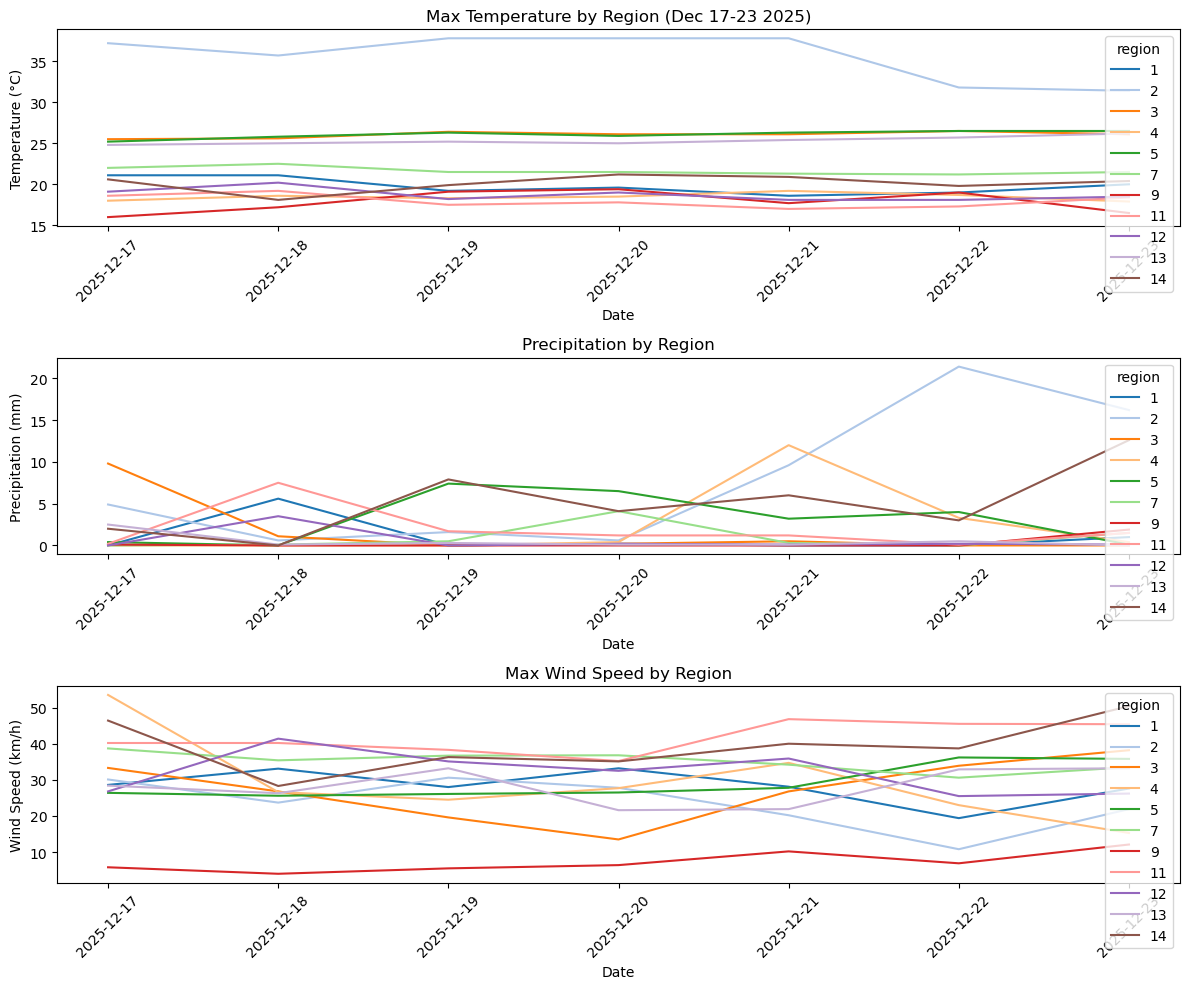

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(12,10))

sns.lineplot(data = weather_data, x = "time", y = "temperature_2m_max", hue = "region", palette = "tab20", ax = axes[0])
axes[0].set_title("Max Temperature by Region (Dec 17-23 2025)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Temperature (°C)")
axes[0].tick_params(axis = "x", rotation = 45)

sns.lineplot(data = weather_data, x = "time", y = "precipitation_sum", 
             hue = "region", palette = "tab20", ax = axes[1])
axes[1].set_title("Precipitation by Region")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].tick_params(axis = "x", rotation = 45)

sns.lineplot(data = weather_data, x = "time", y = "windspeed_10m_max", 
             hue = "region", palette = "tab20", ax = axes[2])
axes[2].set_title("Max Wind Speed by Region")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Wind Speed (km/h)")
axes[2].tick_params(axis = "x", rotation = 45)

plt.tight_layout()
plt.show()



In terms of precipitation and temperature region 2 seems to have the largest values. Region 2 is around Australia and Oceania and is one of the regions with more observations indicating that there is a lot of lightning activity in that area. The OpenMeteos weather data seems to be backing this up by showing more extreme weather for region 2. Region 3 and 5 seems the be the regions with the second highest temperature and these two regions also have a lot of lightning observations. Region 9 seems to have among the "calmest" weather and this is a region with fewer observations. Group 7 has the fewest observations, but seems to be in the middle in terms of weather strength. But when looking at the map it can also be seen that 7 is in the Atlantic outside of west Africa, so it might also depend on from where Open Meteo is taking the weather information for this region. Also more intesive weather does not necessarily always imply ligthning but I think it is interesting to see that the weather information and this data set does mostly align with each other. 

## Conclusion

It is very interesting to see that the OpenMeteo results and the amount of observations per region actually align to a large extent. With building predictive models related to ligtning strikes it has to be taken into account that lightning strikes in themselves are very volatile and difficult to predict. I also highly doubt that the dataset consists of enough different variables to build a extremely good predicitve model. With this taken into account the accuracy of 0.48 is quite good. It was also interesting to see that the model was very unevenly succsful with predicting, managing to predict 97% correctly in one group and only 6% in another. The thing that can be seen from the map is that many regions are overlapping with each other which probably makes predicting a lot more difficult. This is probably also why the k-clusters changes up the observations in different groups a lot compared to the original regions. 

## Exporting the Data and Results

In [69]:
#raw data
lightningdata.to_csv("exports/lightning_data.csv", index=False)

#classification results
results_df = X_test.copy()
results_df["actual_region"] = y_test
results_df["predicted_region"] = predictions
results_df.to_csv("exports/classification_results.csv", index=False)




In [71]:

#cluster results
lightningdata.to_csv("exports/lightning_clusters.csv", index=False)

### Statement of AI use

Claude AI has been used to help writing code, especially with errors and coding some of the more advanced graphs like the map graph. AI has also at some points been used to help understanding some of the results if help had been needed to understand them. 